# Photometry at Different z
In this section we will be looking at how a different z value would effect the SEDs and photometry

### Set-Up

Imports

In [13]:
import os
import math
import numpy as np
import bagpipes as pipes
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl

Setting up Latex formatting

In [14]:
os.environ["PATH"] += r";D:\code\miktex\bin\x64"

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

Importing filters

In [15]:
filter_folder = r"D:\Users\nina\Star_Formation_Histories\Filters"

filter_files = sorted([
    os.path.join(filter_folder, f)
    for f in os.listdir(filter_folder)
    if f.endswith(".txt")
])

global_min = np.inf
global_max = -np.inf

for ffile in filter_files:
    data = np.loadtxt(ffile)
    global_min = min(global_min, data[:,0].min())
    global_max = max(global_max, data[:,0].max())

print(f"Wavelength coverage: {global_min:.0f}–{global_max:.0f} Å")

Wavelength coverage: 3526–50996 Å


### Defining the Model

Defining Parameters

In [ ]:
ages_myr_1 = np.arange(0,110,10)
ages_myr_2 = np.arange(200,1100,100)
years = np.concatenate([ages_myr_1, ages_myr_2]) / 1000

dust = {
    "type": "Calzetti",
    "Av": 0.2,
    "eta": 2.
}

nebular = {
    "logU": -3.
}

z = 2

In [17]:
def burst_model(t, z, dust, nebular):
    return {
        "redshift": z,
        "burst": {"age": t, "massformed": 10, "metallicity": 0.5},
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }


def compute_filter_wavelengths(filter_files):
    eff_waves = []
    for ffile in filter_files:
        filt_data = np.loadtxt(ffile)
        wave = filt_data[:, 0]
        transmission = filt_data[:, 1]
        eff_wave = np.sum(wave * transmission) / np.sum(transmission)
        eff_waves.append(eff_wave)
    return np.array(eff_waves)


def build_models(years, z, dust, nebular, filter_files, wavelength_range):

    models = []

    for t in years:
        components = burst_model(t, z, dust, nebular)

        model = pipes.model_galaxy(
            components,
            filt_list=filter_files,
            spec_wavs=wavelength_range
        )

        models.append(model)

    return models


def plot_model_grid(models, years, filter_wavelengths, ncols=4):

    n = len(models)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(16, 4*nrows))
    axes = axes.flatten()

    for i, model in enumerate(models):

        ax = axes[i]
        spectrum = model.spectrum[:, 1]

        ax.plot(model.spec_wavs, spectrum,
                color='violet', alpha=0.7)

        ax.scatter(filter_wavelengths,
                   model.photometry,
                   color='mediumslateblue', s=20)

        ax.set_xscale('log')
        ax.set_yscale('log')

        positive_flux = spectrum[spectrum > 0]
        if len(positive_flux) > 0:
            ax.set_ylim(positive_flux.min()*0.8,
                        positive_flux.max()*1.2)

        ax.set_title(f"{years[i]:.2f} Gyr", fontsize=9)

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle("Synthetic photometry for different burst ages")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

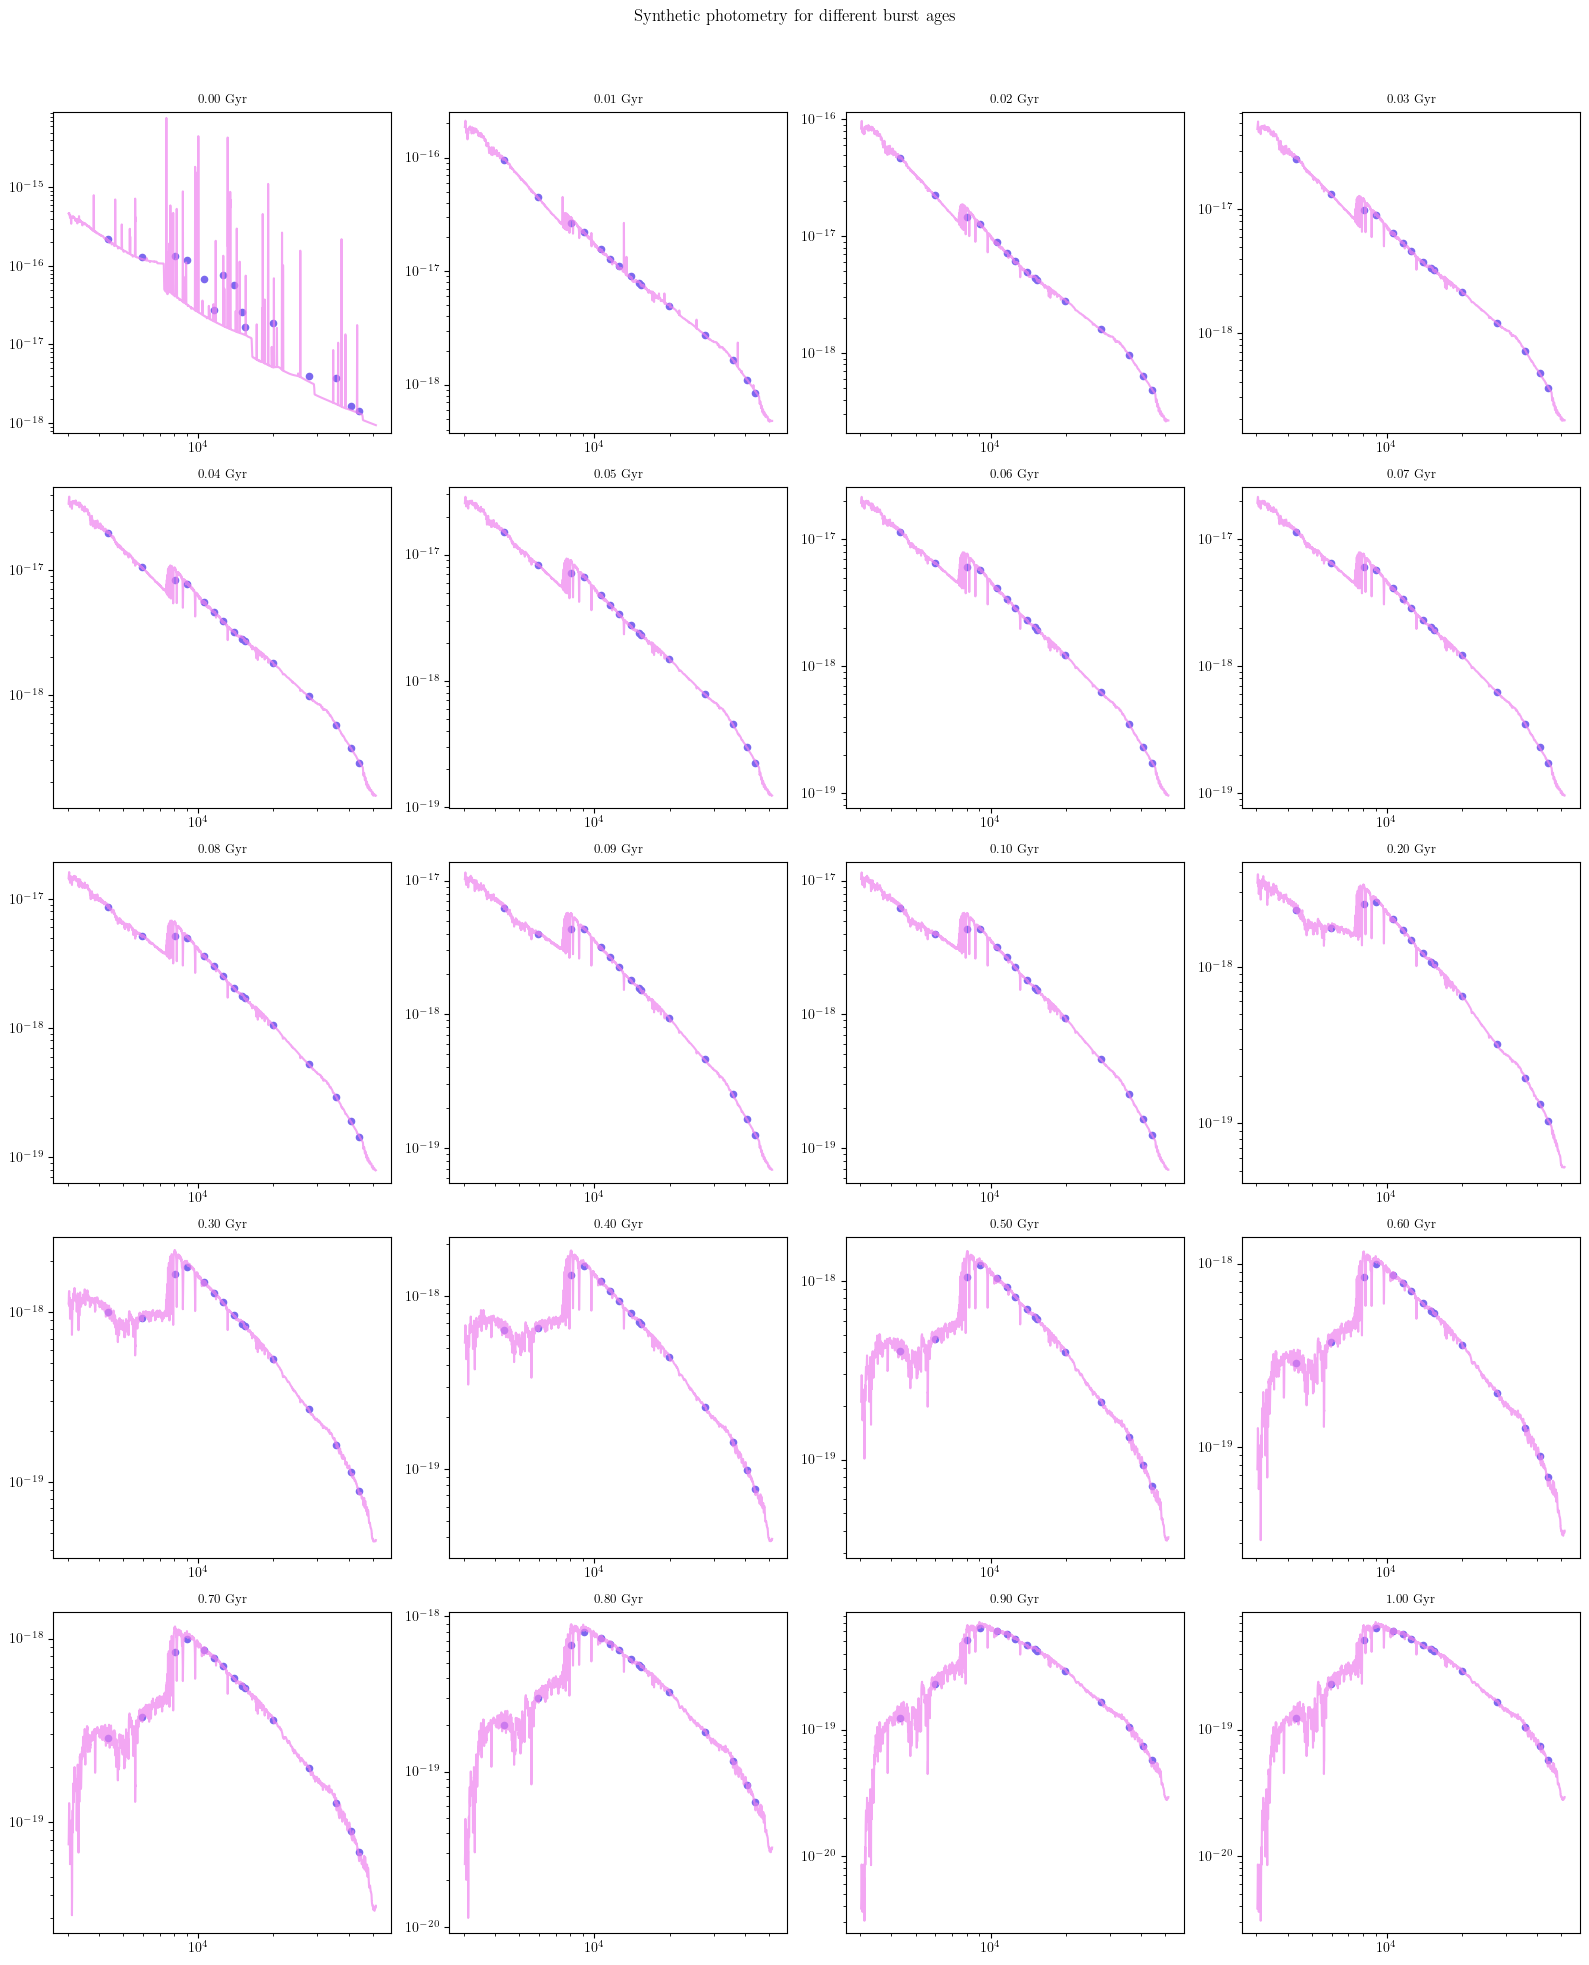

In [18]:
wavelength_range = np.arange(
    global_min - 500,
    global_max + 500,
    5.
)

filter_wavelengths = compute_filter_wavelengths(filter_files)

models = build_models(
    years,
    z,
    dust,
    nebular,
    filter_files,
    wavelength_range
)

plot_model_grid(
    models,
    years,
    filter_wavelengths
)

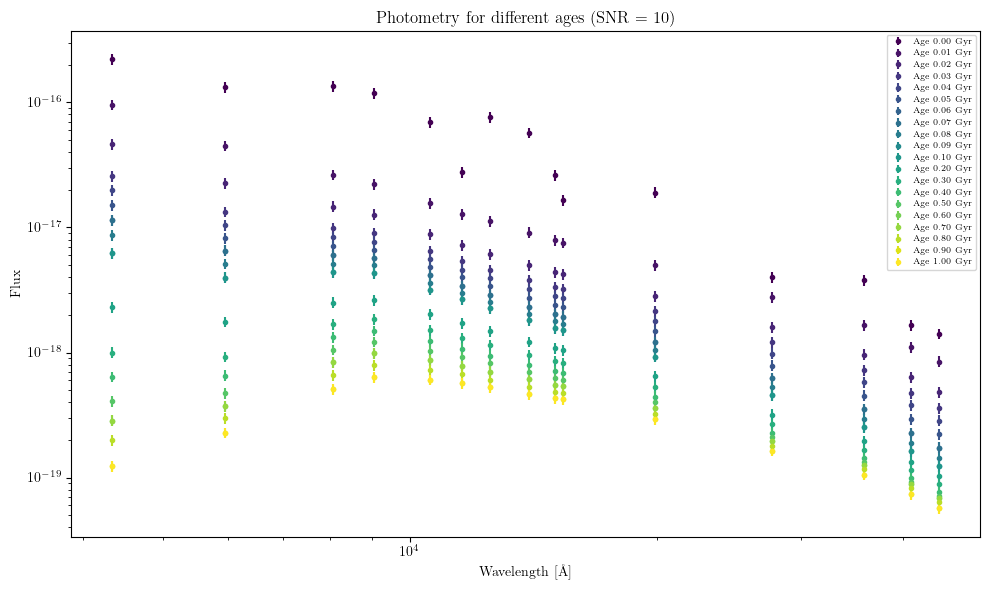

In [ ]:
SNR = 10 

colors = cm.viridis(np.linspace(0, 1, len(years)))

plt.figure(figsize=(10,6))

for i, model in enumerate(models):

    flux = model.photometry
    sigma = flux / SNR 

    plt.errorbar(
        filter_wavelengths,
        flux,
        yerr=sigma,
        fmt='.',
        color=colors[i],
        capsize=0,
        label=f"Age {years[i]:.2f} Gyr"
    )

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Wavelength [Å]")
plt.ylabel("Flux")
plt.title(f"Photometry for different ages (SNR = {SNR})")
plt.legend(fontsize=6, loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:

synthetic_flux = np.array([model.photometry for model in models]) 
synthetic_err  = synthetic_flux / SNR                               

age_idx = len(years)//2

galaxy_photometry = np.c_[
    synthetic_flux[age_idx],
    synthetic_err[age_idx]
]

galaxy = pipes.galaxy(
    "synthetic",                         # arbitrary ID
    lambda ID: galaxy_photometry,        # function returning photometry
    spectrum_exists=False,
    filt_list=filter_files
)

In [21]:
# Exponential SFH
exp = {
    "age": (0.1, 15.),            # in Gyr
    "tau": (0.3, 10.),            # in Gyr
    "massformed": (1., 15.),      # log10(M*/M_sun)
    "metallicity": (0., 2.5)      # Z/Z_sun
}

# Dust
dust_fit = {
    "type": "Calzetti",
    "Av": (0., 2.)
}

# Fit instructions
fit_instructions = {
    "redshift": (0., 10.),
    "exponential": exp,
    "dust": dust_fit
}

In [ ]:
fit = pipes.fit(galaxy, fit_instructions)

# Run MCMC
fit.fit(verbose=False)

MultiNest not available. Switching to nautilus.

Bagpipes: fitting object synthetic



In [ ]:
# Posterior samples
samples = fit.posterior.samples

# Median values
print("Stellar mass:", np.median(samples["stellar_mass"]))
print("SFR - Mass:", np.median(np.log10(samples["sfr"]) - samples["stellar_mass"]))
print("Mass-weighted age (16-84%):", np.percentile(samples["mass_weighted_age"], (16, 84)))

# Advanced quantities
fit.posterior.get_advanced_quantities()

In [ ]:
fig = fit.plot_spectrum_posterior(save=False, show=True)
fig = fit.plot_sfh_posterior(save=False, show=True)
fig = fit.plot_corner(save=False, show=True)
plt.close(fig)

# Optional: a custom grid for photometry + posterior histograms
import matplotlib.pyplot as plt
import matplotlib as mpl

fig = plt.figure(figsize=(12, 7))
gs = mpl.gridspec.GridSpec(7, 4, hspace=3., wspace=0.1)

ax1 = plt.subplot(gs[:4, :])

pipes.plotting.add_observed_photometry(fit.galaxy, ax1, zorder=10)
pipes.plotting.add_photometry_posterior(fit, ax1)

labels = ["sfr", "mass_weighted_age", "stellar_mass", "ssfr"]
post_quantities = dict(zip(labels, [samples[l] for l in labels]))

axes = []
for i in range(4):
    axes.append(plt.subplot(gs[4:, i]))
    pipes.plotting.hist1d(post_quantities[labels[i]], axes[-1], smooth=True, label=labels[i])

plt.show()